<a href="https://colab.research.google.com/github/giharajayasinghe/malaria-cell-classification-cnn/blob/main/Cnn_classificiation_changed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch.nn as nn
import numpy as np
from matplotlib import pyplot as plt
import deeplay as dl
import torch
import os
from torchvision.datasets.utils import _extract_zip,download_url

In [ ]:
#First we get the data
data_path = os.path.join('.','blood_smears_dataset')
if not os.path.exists(data_path):
  download_url('https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip','.')
  _extract_zip('cell_images.zip',data_path,None)
  os.remove('cell_images.zip')

100%|██████████| 353M/353M [00:01<00:00, 180MB/s]


In [ ]:
from torchvision.datasets import ImageFolder
base_dir = os.path.join(data_path,'cell_images')
dataset = ImageFolder(base_dir)

In [ ]:
#So here you can see the plots of the cells.
def plot_blood_smears(dataset,parasitized):
  fig,axl = plt.subplots(figsize=(15,6),nrows=3,ncols=10)
  for ax in axl.ravel():
    i = np.random.randint(0,len(dataset))
    image,label = dataset[i]
    if isinstance(image,torch.Tensor):
      image,label = image.numpy().transpose(1,2,0),label.numpy()
    ax.imshow(image)
    ax.set_title(f'Parasitized ({label})' if label == parasitized else
                 f'Uninfected ({label})',fontsize = 10)
  plt.tight_layout()
  plt.show()


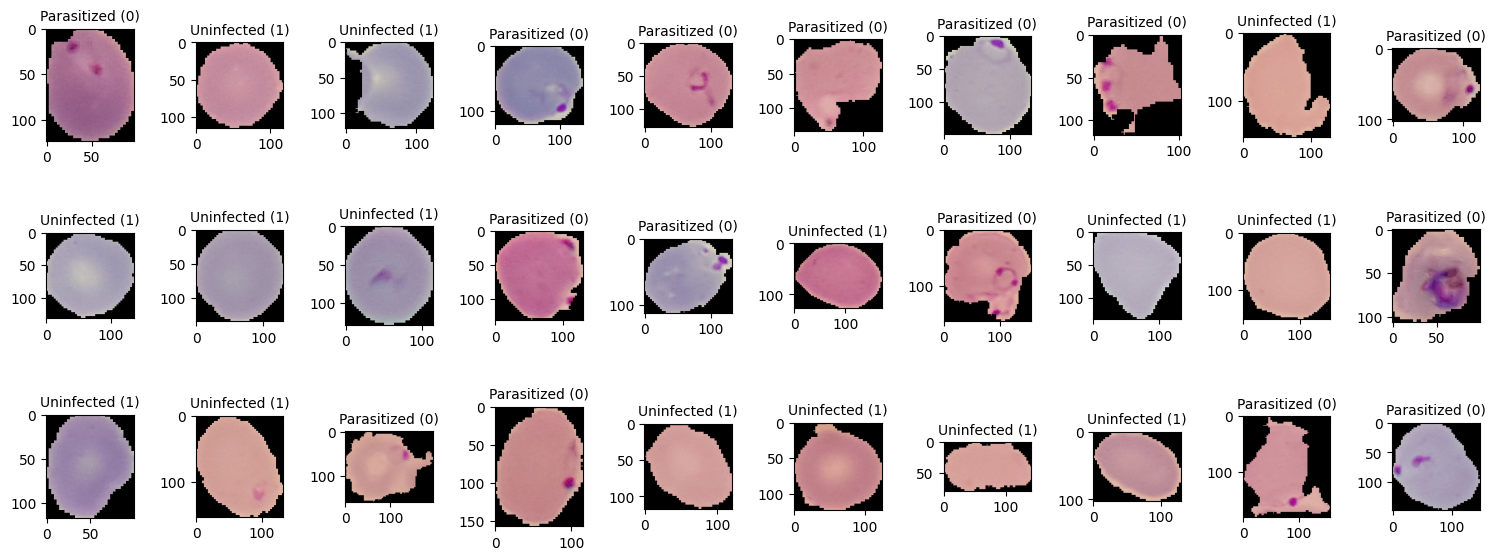

In [ ]:
plot_blood_smears(dataset,0)

In [ ]:
#So here there are many different pixal sized images, so we make all the same size
from torchvision.transforms import Compose,Resize,ToTensor
image_trans = Compose([Resize((28,28)),ToTensor()])

In [ ]:
def label_trans(label):
  return torch.tensor(1-label).float().unsqueeze(-1)

In [ ]:
dataset_new = ImageFolder(base_dir,
                          transform=image_trans,
                          target_transform=label_trans)

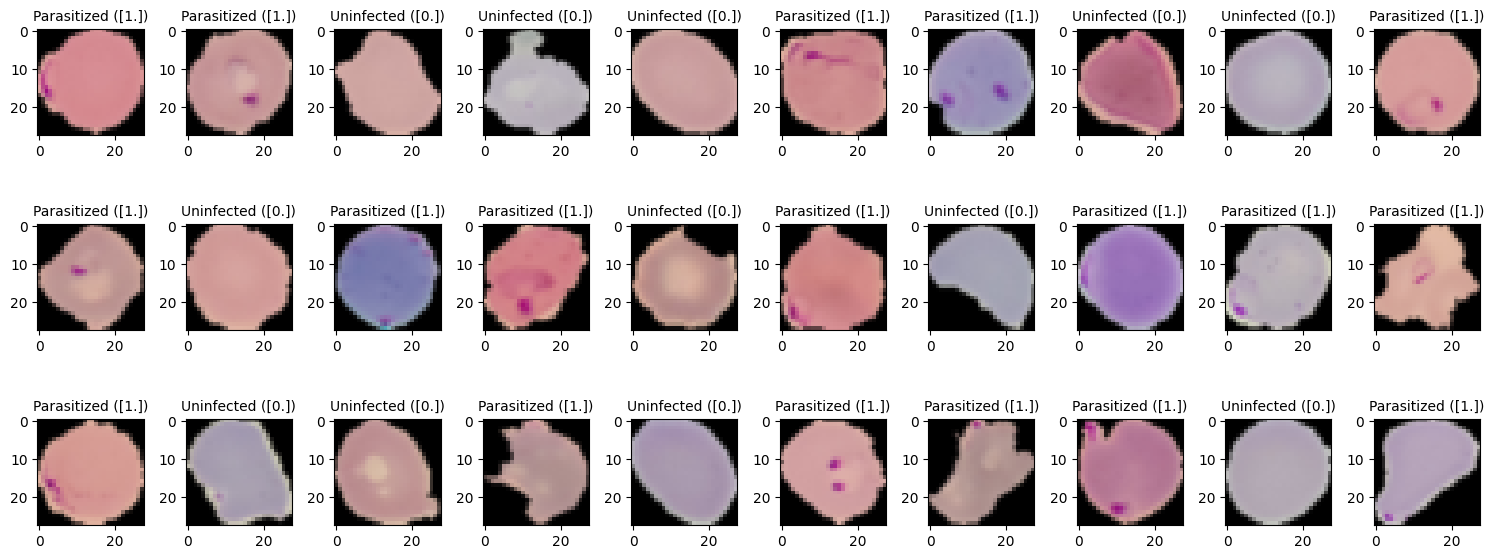

In [ ]:
plot_blood_smears(dataset_new,1)

In [ ]:
#splitting the data into train and test data
train,test = torch.utils.data.random_split(dataset_new,[0.8,0.2])

In [ ]:
#Creating train and test data loaders
train_loader = torch.utils.data.DataLoader(
    train,batch_size=32,shuffle=True,
)
test_loader = torch.utils.data.DataLoader(
    test,batch_size=256,shuffle=True
)


In [ ]:
from torch.nn.modules import activation
#first i am implementing a dense neural network without using cnn
dnn = dl.MultiLayerPerceptron(
    in_features=28*28*3,
    hidden_features=[128,128],
    out_features=1,
    out_activation=torch.nn.Sigmoid
).create()

In [ ]:
print(dnn)

MultiLayerPerceptron(
  (blocks): LayerList(
    (0): LinearBlock(
      (layer): Linear(in_features=2352, out_features=128, bias=True)
      (activation): ReLU()
    )
    (1): LinearBlock(
      (layer): Linear(in_features=128, out_features=128, bias=True)
      (activation): ReLU()
    )
    (2): LinearBlock(
      (layer): Linear(in_features=128, out_features=1, bias=True)
      (activation): Sigmoid()
    )
  )
)


In [ ]:
dnn_classifier = dl.BinaryClassifier(
    model=dnn,
    optimizer=dl.Adam(lr=0.001)
).create()

In [ ]:
dnn_trainer = dl.Trainer(max_epochs=5,accelerator='auto')
dnn_trainer.fit(dnn_classifier,train_loader)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss              │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │     0 │
│ 4 │ model         │ MultiLayerPerceptron │  317 K │ train │     0 │
│ 5 │ optimizer     │ Adam                 │      0 │ train │     0 │
└───┴───────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 317 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 317 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 19                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
import torchmetrics as tm
#plotting the roc curve
def plot_roc(classifier,loader):
  roc=tm.ROC(task='binary')
  for image,label in loader:
    roc.update(classifier(image),label.long())

  fig,ax = roc.plot(score=True)
  ax.grid(False)
  ax.axis('square')
  ax.set_xlim(0,1)
  ax.set_ylim(0,1)
  ax.legend(loc='center right')
  plt.show()

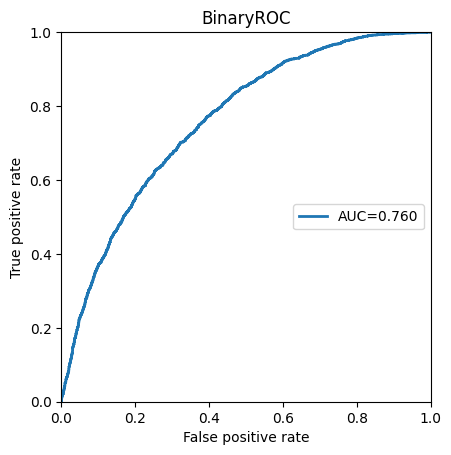

In [ ]:
plot_roc(dnn_classifier,test_loader)

In [ ]:
from deeplay.external.layer import in_features
#we create a cnn to like show the difference in capabilites

cnn_base = dl.ConvolutionalNeuralNetwork(
    in_channels=3,
    hidden_channels=[16,16,32],
    out_channels=32,
)
cnn_base.blocks[2].pool.configure(nn.MaxPool2d,kernel_size=2)

connector = dl.Layer(
    nn.AdaptiveAvgPool2d,output_size=1
)

dense_top = dl.MultiLayerPerceptron(
    in_features=32,
    hidden_features=[],
    out_features=1,
    out_activation=nn.Sigmoid,
)

cnn = dl.Sequential(
    cnn_base,connector,dense_top
)


In [ ]:
cnn_classifier = dl.BinaryClassifier(
    model=cnn,
    optimizer=dl.RMSprop(lr=0.001),
).create()

In [ ]:
trainer_new = dl.Trainer(max_epochs=5,accelerator='auto')
trainer_new.fit(cnn_classifier,train_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │ 16.7 K │ train │     0 │
│ 5 │ optimizer     │ RMSprop          │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 16.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: |          | 0/? [00:00<?, ?it/s]

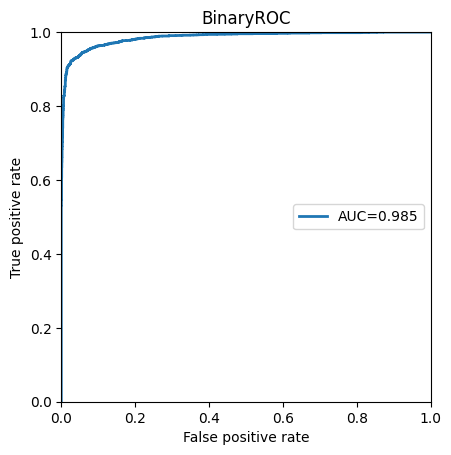

In [ ]:
plot_roc(cnn_classifier,test_loader)

In [ ]:
import nbformat

nb = nbformat.read("drive/MyDrive/Colab Notebooks/Cnn_classification.ipynb", as_version=nbformat.NO_CONVERT)

if "widgets" in nb.metadata:
    nb.metadata["widgets"].setdefault("state", {})
else:
    nb.metadata["widgets"] = {"state": {}}

nbformat.write(nb, "drive/MyDrive/Colab Notebooks/Cnn_classificiation_new.ipynb.ipynb")

In [ ]:
import nbformat

nb = nbformat.read("notebook.ipynb", as_version=nbformat.NO_CONVERT)

if "widgets" in nb.metadata:
    if "state" not in nb.metadata["widgets"]:
        nb.metadata["widgets"]["state"] = {}

nbformat.write(nb, "notebook_fixed.ipynb")

In [ ]:
import nbformat

nb = nbformat.read("drive/MyDrive/Colab Notebooks/Cnn_classification.ipynb", as_version=nbformat.NO_CONVERT)

if "widgets" in nb.metadata:
    nb.metadata["widgets"].setdefault("state", {})
else:
    nb.metadata["widgets"] = {"state": {}}

nbformat.write(nb, "drive/MyDrive/Colab Notebooks/Cnn_classificiation_new.ipynb.ipynb")